In [ ]:
import numpy as np
from astropy.table import Table, join
from gaiaxpy import calibrate

import matplotlib.pyplot as plt

In [9]:
# Load catalogs
tab_var = Table.read('../data/gaia_vari_agn.fits')
tab_quaia = Table.read('../data/quaia_G20.5.fits')
print('gaia_vari_agn:', len(tab_var), '| quaia_G20.5:', len(tab_quaia))

gaia_vari_agn: 872228 | quaia_G20.5: 1295502


In [13]:
# Join on source_id: sources in both catalogs

tab_both = join(tab_var, tab_quaia, keys='source_id')
print('In both:', len(tab_both))

# Only in quaia
mask_quaia_only = ~np.isin(tab_quaia['source_id'], tab_var['source_id'])
tab_quaia_only = tab_quaia[mask_quaia_only]
print('Only in quaia:', len(tab_quaia_only))

# Only in vari_agn
mask_var_only = ~np.isin(tab_var['source_id'], tab_quaia['source_id'])
tab_var_only = tab_var[mask_var_only]
print('Only in vari_agn:', len(tab_var_only))

# Checks: both + only = original
assert len(tab_both) + len(tab_var_only) == len(tab_var), 'vari_agn: both + only != total'
assert len(tab_both) + len(tab_quaia_only) == len(tab_quaia), 'quaia: both + only != total'
print('Checks OK.')

In both: 713816
Only in quaia: 581686
Only in vari_agn: 158412
Checks OK.


In [15]:
# Brightest N sources in quaia by G magnitude
N = 5
col_G = 'phot_g_mean_mag'

idx_bright = np.argsort(tab_quaia[col_G])[:N]
bright_quaia = tab_quaia[['source_id', 'ra', 'dec', col_G]][idx_bright]
print(bright_quaia)

     source_id              ra                 dec         phot_g_mean_mag
                           deg                 deg               mag      
------------------- ------------------ ------------------- ---------------
2160562892865099392 275.48838755295634   64.34339482479527        13.88239
 716567571957977088 131.92686903434102  34.751245058775424       14.312966
3536437524196768896 167.22065141973226 -23.636520416538307      14.4405985
3189105374395563264  61.95179574727074  -12.19351663570421      14.4952545
1597998215189326080  234.1600048772804  54.559226512092955       14.538776


In [24]:
# Source IDs of the N brightest quaia sources
bright_quaia_ids = list(bright_quaia['source_id'])
print(bright_quaia_ids)


[2160562892865099392, 716567571957977088, 3536437524196768896, 3189105374395563264, 1597998215189326080]


In [53]:
# from astroquery.gaia import Gaia

# # Count how many of a subset of tab_quaia have XP spectra
# # (increase N_ids if desired, but very large lists can slow the query)
# #N_ids = 1000
# #src_ids = tab_quaia['source_id'][:N_ids]
# src_ids = tab_quaia['source_id']

# id_list_str = ",".join(str(int(s)) for s in src_ids)

# adql = f"""
# SELECT COUNT(*) AS n_with_xp
# FROM gaiadr3.gaia_source
# WHERE SOURCE_ID IN ({id_list_str})
#   AND has_xp_continuous = 'true'
# """

# job = Gaia.launch_job_async(adql)
# count_tab = job.get_results()
# print(count_tab)

In [46]:
from astropy.table import Table
from astroquery.gaia import Gaia

# Faster: upload our source_ids as a table and let Gaia do the join
#N_ids = 100000  # adjust as needed (larger is slower)
N_ids = len(tab_quaia)
ids_tab = Table()
ids_tab['source_id'] = tab_quaia['source_id'][:N_ids]

adql = """
SELECT COUNT(*) AS n_with_xp
FROM gaiadr3.gaia_source AS g
JOIN TAP_UPLOAD.ids AS u
  ON g.source_id = u.source_id
WHERE g.has_xp_continuous = 'true'
"""

job = Gaia.launch_job_async(adql, upload_resource=ids_tab, upload_table_name='ids')
count_tab = job.get_results()
print(count_tab)

INFO: Query finished. [astroquery.utils.tap.core]
n_with_xp
---------
   115104


In [ ]:
# List of source_ids (from same subset) that have XP spectra
# Uses same ids_tab as count cell; run that cell first or redefine ids_tab here
adql_list = """
SELECT g.source_id
FROM gaiadr3.gaia_source AS g
JOIN TAP_UPLOAD.ids AS u
  ON g.source_id = u.source_id
WHERE g.has_xp_continuous = 'true'
"""

job_list = Gaia.launch_job_async(adql_list, upload_resource=ids_tab, upload_table_name='ids')
tab_xp_source_ids = job_list.get_results()
# Rename if Gaia returns SOURCE_ID
if 'SOURCE_ID' in tab_xp_source_ids.colnames:
    tab_xp_source_ids.rename_column('SOURCE_ID', 'source_id')
source_ids_with_xp = list(tab_xp_source_ids['source_id'])
print(f'N with XP spectra: {len(source_ids_with_xp)}')
print(source_ids_with_xp[:10])

INFO: Query finished. [astroquery.utils.tap.core]
N with XP spectra: 115104
[79335093999019520, 288802367011984128, 293084582549633920, 304891967338094848, 313787596226783872, 325789319695317760, 369740544668326272, 379748913685892864, 572421799418370816, 588786277651050752]


In [57]:
# Quaia table restricted to sources that have XP spectra
tab_has_xp = tab_quaia[np.isin(tab_quaia['source_id'], source_ids_with_xp)]
print(f'tab_has_xp: {len(tab_has_xp)} rows')

tab_has_xp: 115104 rows


In [56]:
print(f"{len(tab_xp_source_ids)}/{len(tab_quaia)} ({100*len(tab_xp_source_ids)/len(tab_quaia):.1f}%) of quaia sources have XP spectra")

115104/1295502 (8.9%) of quaia sources have XP spectra


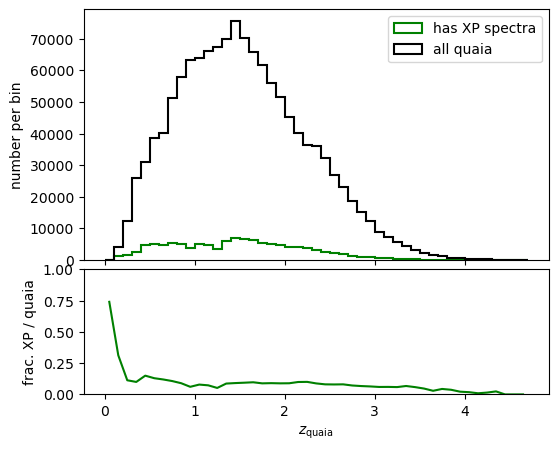

In [71]:
color_quaia = 'black'
color_xp = 'green'
bin_width = 0.1
bin_edges = np.arange(0, np.max(tab_quaia['redshift_quaia']) + bin_width, bin_width)
count_xp, _ = np.histogram(tab_has_xp['redshift_quaia'], bins=bin_edges)
count_quaia, _ = np.histogram(tab_quaia['redshift_quaia'], bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
frac = np.where(count_quaia > 0, count_xp / count_quaia, np.nan)

fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_top.hist(tab_has_xp['redshift_quaia'], bins=bin_edges, histtype='step', label='has XP spectra', color=color_xp, linewidth=1.5)
ax_top.hist(tab_quaia['redshift_quaia'], bins=bin_edges, histtype='step', label='all quaia', color=color_quaia, linewidth=1.5)
ax_top.set_ylabel('number per bin')
ax_top.legend()

ax_bot.plot(bin_centers, frac, color=color_xp, linewidth=1.5)
ax_bot.set_xlabel(r'$z_{\rm quaia}$')
ax_bot.set_ylabel('frac. XP / quaia')
ax_bot.set_ylim(0.0, 1)
plt.show()


/var/folders/r3/x5f9h97x5yxcdy7qv3t1pr7m0000gn/T/ipykernel_41210/4131457913.py:6: RuntimeWarning: invalid value encountered in divide
  frac = np.where(count_quaia > 0, count_xp / count_quaia, np.nan)


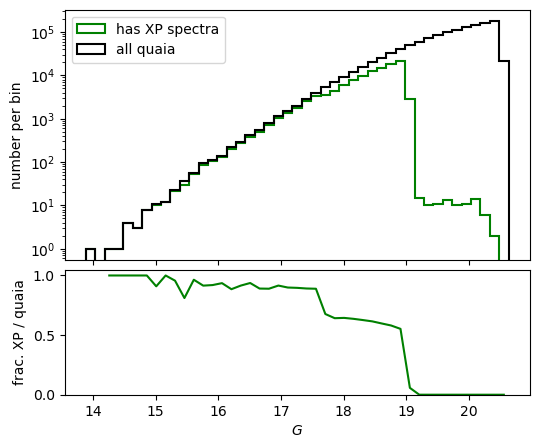

In [74]:
bin_width = 0.15
bin_edges = np.arange(np.min(tab_quaia[col_G]), np.max(tab_quaia[col_G]) + bin_width, bin_width)
count_xp, _ = np.histogram(tab_has_xp[col_G], bins=bin_edges)
count_quaia, _ = np.histogram(tab_quaia[col_G], bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
frac = np.where(count_quaia > 0, count_xp / count_quaia, np.nan)

fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_top.hist(tab_has_xp[col_G], bins=bin_edges, histtype='step', label='has XP spectra', 
            color=color_xp, linewidth=1.5)
ax_top.hist(tab_quaia[col_G], bins=bin_edges, histtype='step', label='all quaia', 
            color=color_quaia, linewidth=1.5)
ax_top.set_ylabel('number per bin')
ax_top.set_yscale('log')
ax_top.legend()

ax_bot.plot(bin_centers, frac, color=color_xp, linewidth=1.5)
ax_bot.set_xlabel(r'$G$')
ax_bot.set_ylabel('frac. XP / quaia')
ax_bot.set_ylim(0, 1.05)
plt.show()


In [115]:
from astroquery.gaia import Gaia

col_G = 'phot_g_mean_mag'
# Pick brightest source with XP spectra per redshift bin (9 bins up to z=4.5)
z_edges = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
ids_to_fetch = []
z_bin_labels = []
for i in range(9):
    mask = (tab_has_xp['redshift_quaia'] >= z_edges[i]) & (tab_has_xp['redshift_quaia'] < z_edges[i+1])
    if np.any(mask):
        masked_idx = np.where(mask)[0]
        idx = masked_idx[np.argmin(tab_has_xp[col_G][masked_idx])]
        ids_to_fetch.append(tab_has_xp['source_id'][idx])
        z_bin_labels.append(f'{z_edges[i]:.1f} $\leq z <$ {z_edges[i+1]:.1f}')
    else:
        ids_to_fetch.append(None)
        z_bin_labels.append(f'{z_edges[i]:.1f} $\leq z <$ {z_edges[i+1]:.1f} (no source)')

ids_list = [x for x in ids_to_fetch if x is not None]
bin_of_fetched = [i for i in range(9) if ids_to_fetch[i] is not None]
print(f'Fetching XP spectra for {len(ids_list)} sources (one per redshift bin)')

Fetching XP spectra for 9 sources (one per redshift bin)


In [116]:
ids_list

[2160562892865099392,
 716567571957977088,
 1649991749245329152,
 4800195161003160960,
 3961558644193943552,
 2119505646919139328,
 5692283950261702528,
 6747142216109250048,
 2594162755045006080]

In [117]:
from astroquery.gaia import Gaia

# Get XP sampled spectra
datalink = Gaia.load_data(
                          #ids=[1597998215189326080], 
                          ids=ids_list,
                          data_release='Gaia DR3',
                          #retrieval_type='XP_SAMPLED', 
                          retrieval_type='XP_CONTINUOUS', 
                          verbose=True)

# This downloads the spectrum file
# Access the data
spectrum = datalink # First (and only) result
#print(spectrum.columns)  # See what columns are available
#print(spectrum)  # View the data

Retrieving data.
Data request: VALID_DATA=true&ID=2160562892865099392%2C716567571957977088%2C1649991749245329152%2C4800195161003160960%2C3961558644193943552%2C2119505646919139328%2C5692283950261702528%2C6747142216109250048%2C2594162755045006080&RELEASE=Gaia+DR3&DATA_STRUCTURE=INDIVIDUAL&FORMAT=votable&RETRIEVAL_TYPE=XP_CONTINUOUS&USE_ZIP_ALWAYS=true
------>https
host = gea.esac.esa.int:443
context = /data-server/data
Content-type = application/x-www-form-urlencoded
200 200
Reading...
Done.


In [118]:
tab_spec = spectrum[list(spectrum.keys())[0]][0]

In [ ]:
# Your source ID(s)
#bright one
source_ids = [1597998215189326080]

# Convert coefficients to calibrated spectra
# This downloads the coefficients and converts them automatically
calibrated_spectra, sampling = calibrate(source_ids)

# calibrated_spectra is a pandas DataFrame with columns:
# source_id, flux (array), flux_error (array)
# sampling is the wavelength array (in nm)

print("Flux shape:", calibrated_spectra['flux'][0].shape)


Flux shape: (343,) to path: ./output_spectra.csv         0/1 [00:00<?, ?spec/s]


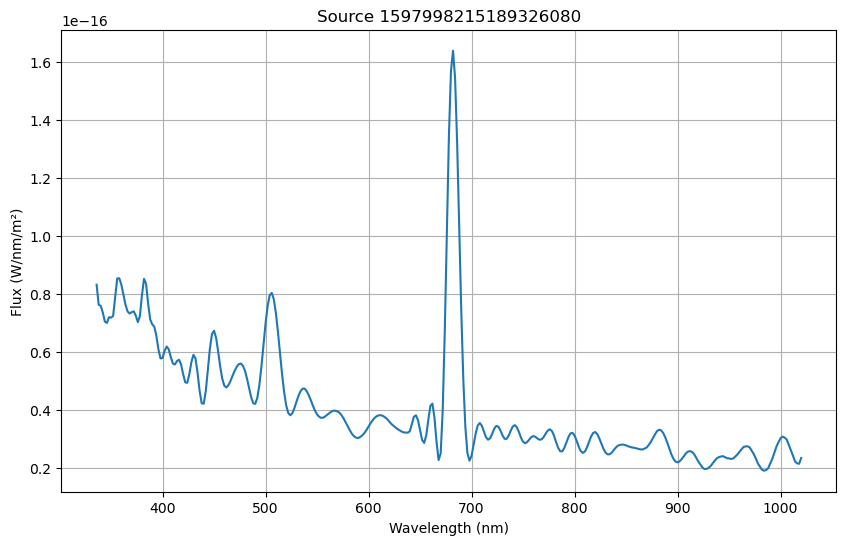

In [120]:

# Plot it
plt.figure(figsize=(10, 6))
plt.plot(sampling, calibrated_spectra['flux'][0])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (W/nm/m²)')
plt.title(f'Source {source_ids[0]}')
plt.grid(True)
plt.show()

In [121]:
calibrated_spectra, sampling = calibrate(ids_list)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


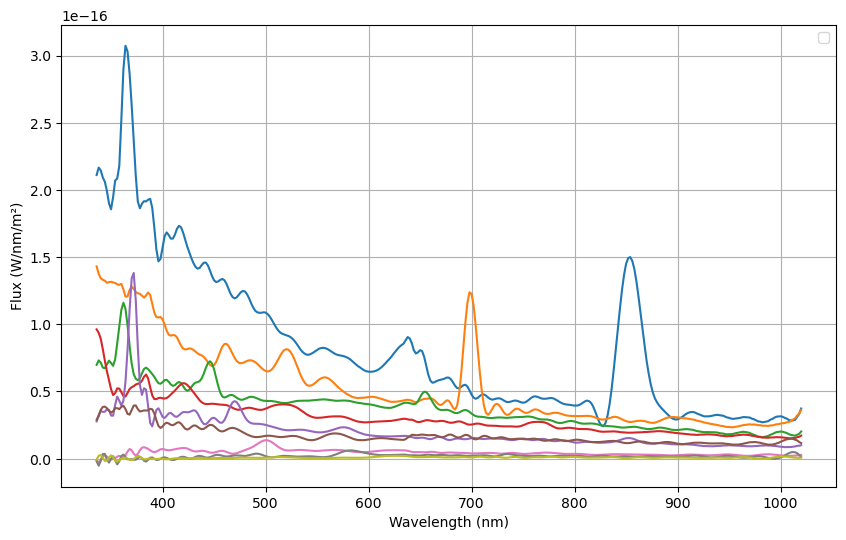

In [122]:
# Plot all
plt.figure(figsize=(10, 6))
for idx, row in calibrated_spectra.iterrows():
    plt.plot(sampling, row['flux'])#, label=f"Source {row['source_id']}", alpha=0.7)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (W/nm/m²)')
plt.legend()
plt.grid(True)
plt.show()

# grab some ra decs for images 

In [50]:
tab_select = tab_quaia[(tab_quaia[col_G]>18)&(tab_quaia[col_G]<19)&(tab_quaia['redshift_quaia']<0.8)]

In [52]:
tab_select['ra', 'dec', 'phot_g_mean_mag', 'redshift_quaia']

ra,dec,phot_g_mean_mag,redshift_quaia
deg,deg,mag,
float64,float64,float32,float64
45.20391785007929,0.9113096392855202,18.18146,0.669161423194202
44.1957090998565,1.2303609927166672,18.253172,0.17577782273292542
45.41331735274704,1.7497082192289903,18.678919,0.20832006672378364
45.253642525314866,1.8246709955842313,18.696598,0.5947461128234863
44.4826091153557,1.7434893915458203,18.590042,0.28144925832748413
44.70800296894258,1.8736280359890969,18.366703,0.6084240674972534
46.23617733991125,2.188245938511342,18.59145,0.2552449107170105
47.05882558041416,2.573103684344736,18.316292,0.5731565952301025


In [ ]:
tab_select['ra', 'dec']

ra,dec
deg,deg
float64,float64
45.20391785007929,0.9113096392855202
44.1957090998565,1.2303609927166672
45.41331735274704,1.7497082192289903
45.253642525314866,1.8246709955842313
44.4826091153557,1.7434893915458203
44.70800296894258,1.8736280359890969
46.23617733991125,2.188245938511342
47.05882558041416,2.573103684344736
